Fitting primary constrained model (200 starts) ...
Bootstrap 50/500
Bootstrap 100/500
Bootstrap 150/500
Bootstrap 200/500
Bootstrap 250/500
Bootstrap 300/500
Bootstrap 350/500
Bootstrap 400/500
Bootstrap 450/500
Bootstrap 500/500
Fitting shallow surrogate and calculating exact Shapley values ...
Saved figure: /content/generated_figures/Figure_1_cluster_projection.png
Saved figure: /content/generated_figures/Figure_2_assignment_stability.png
Saved figure: /content/generated_figures/Figure_3_global_shapley.png


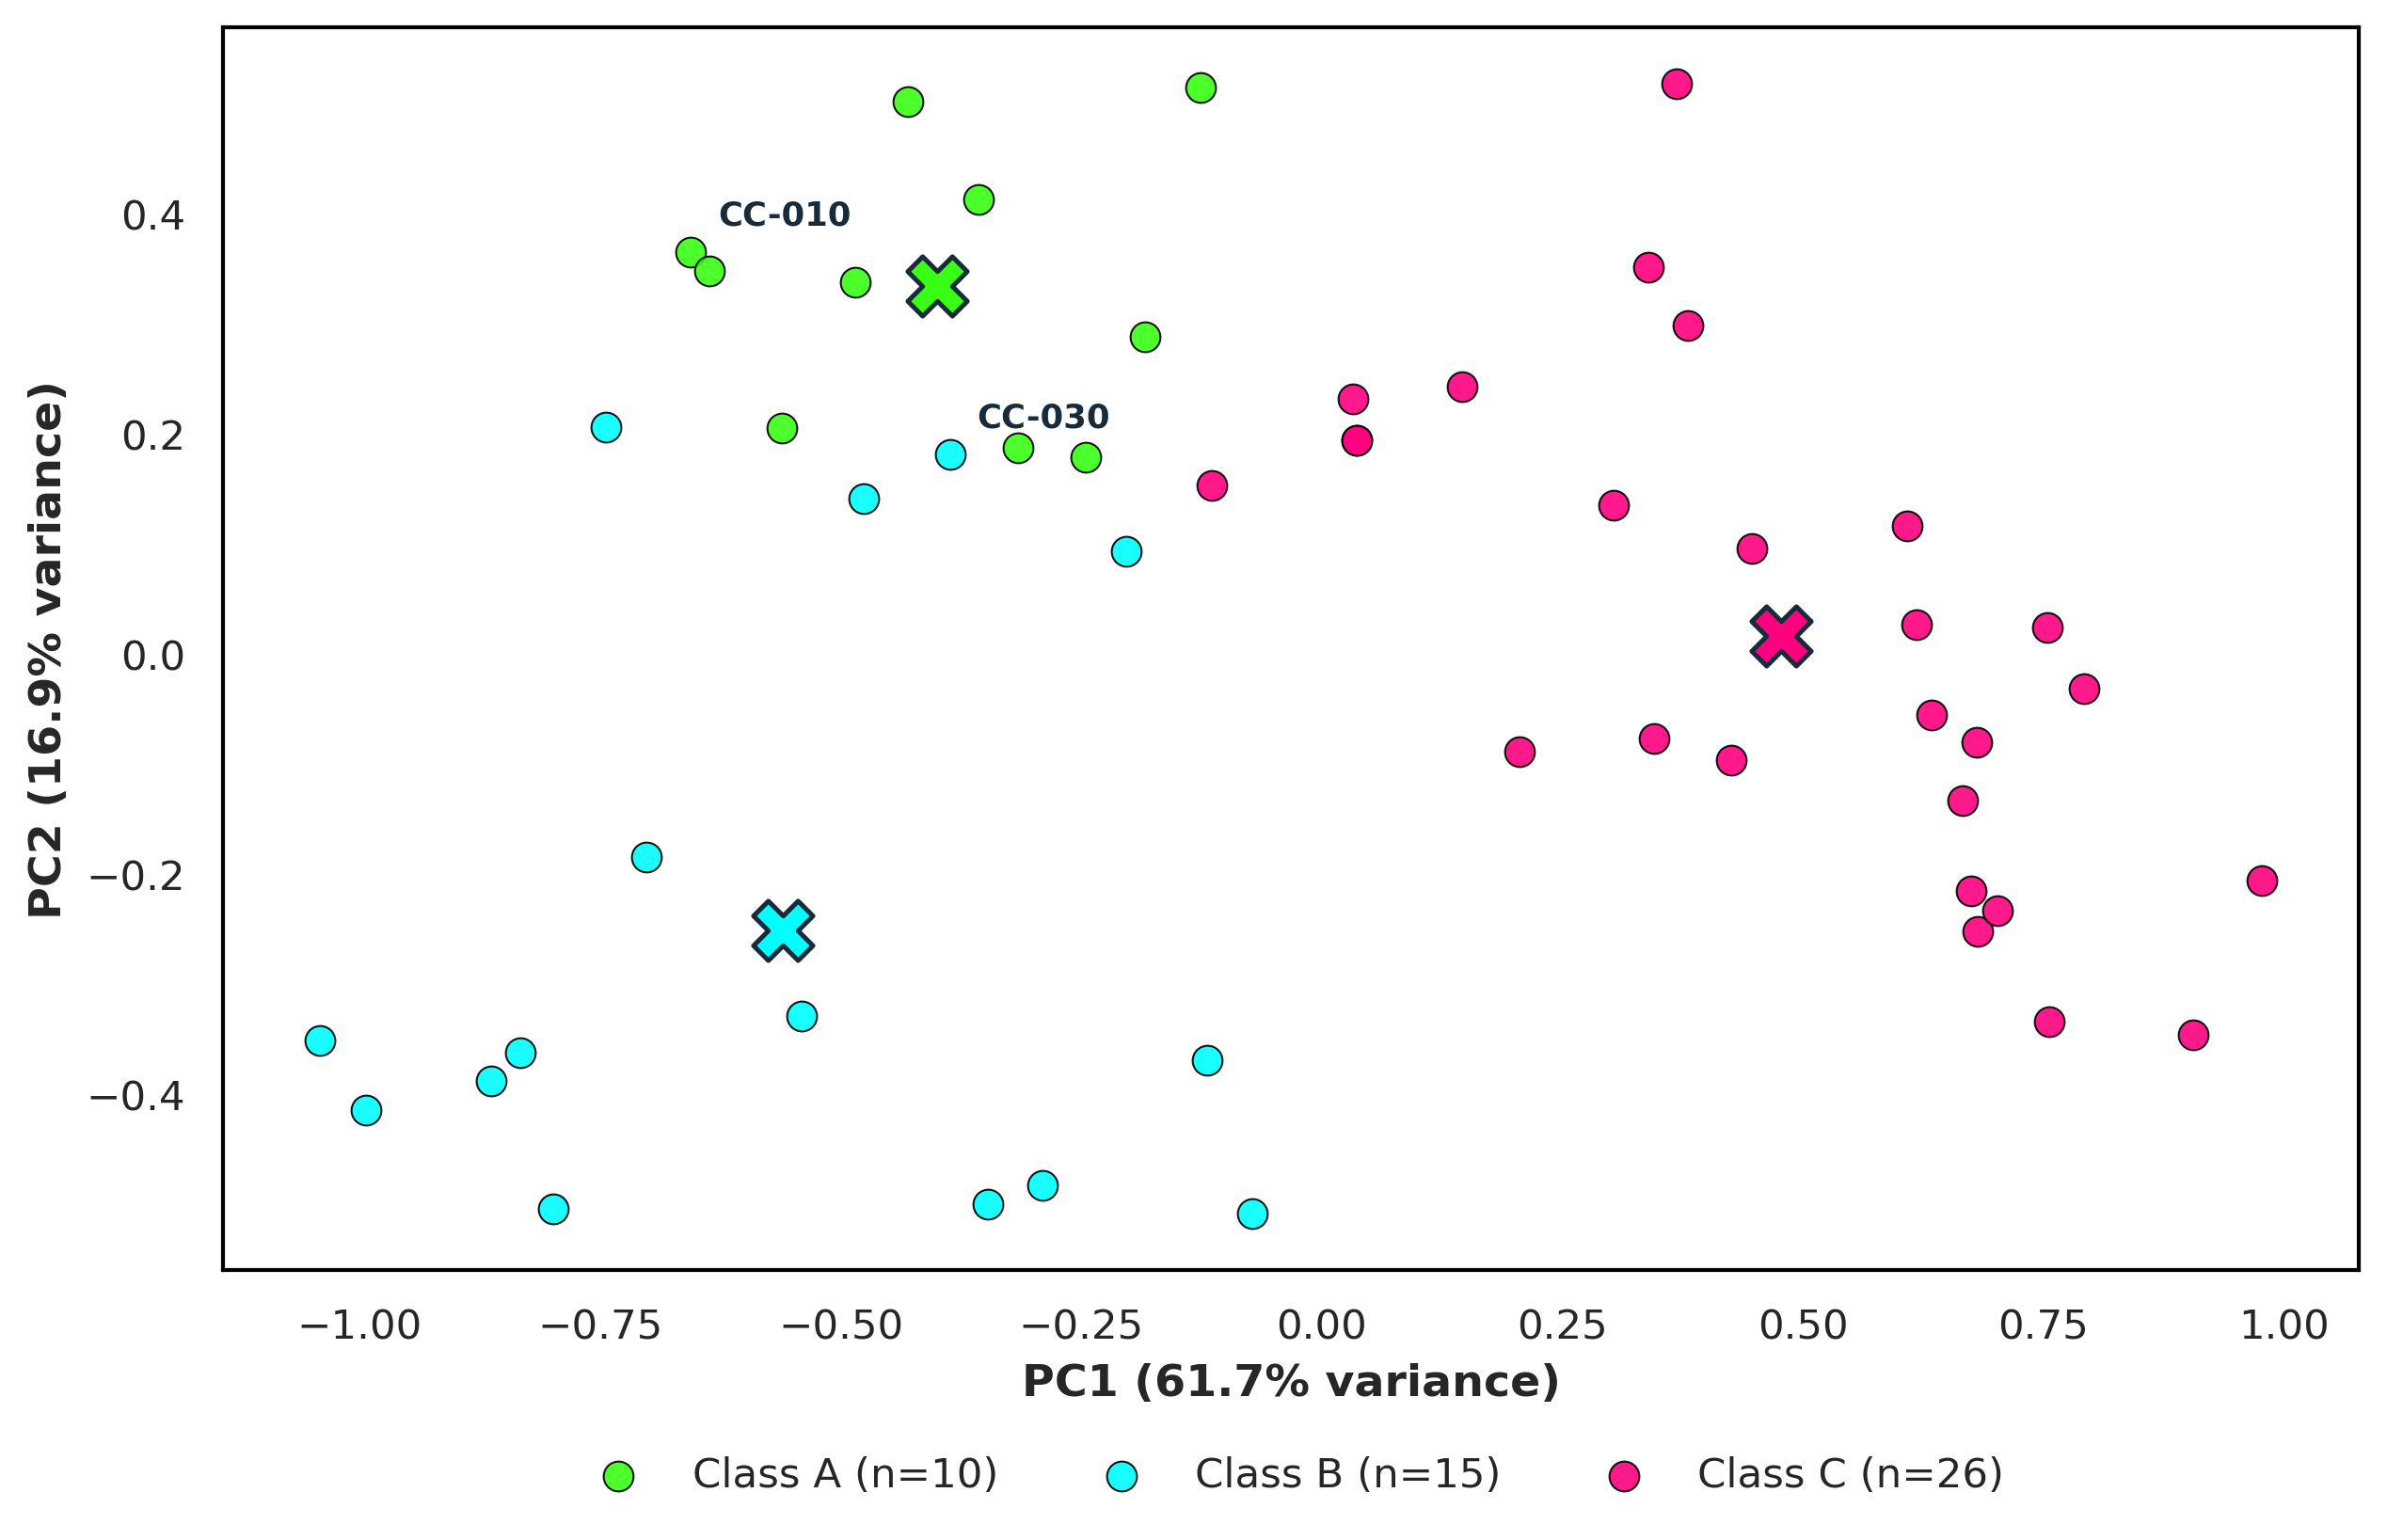

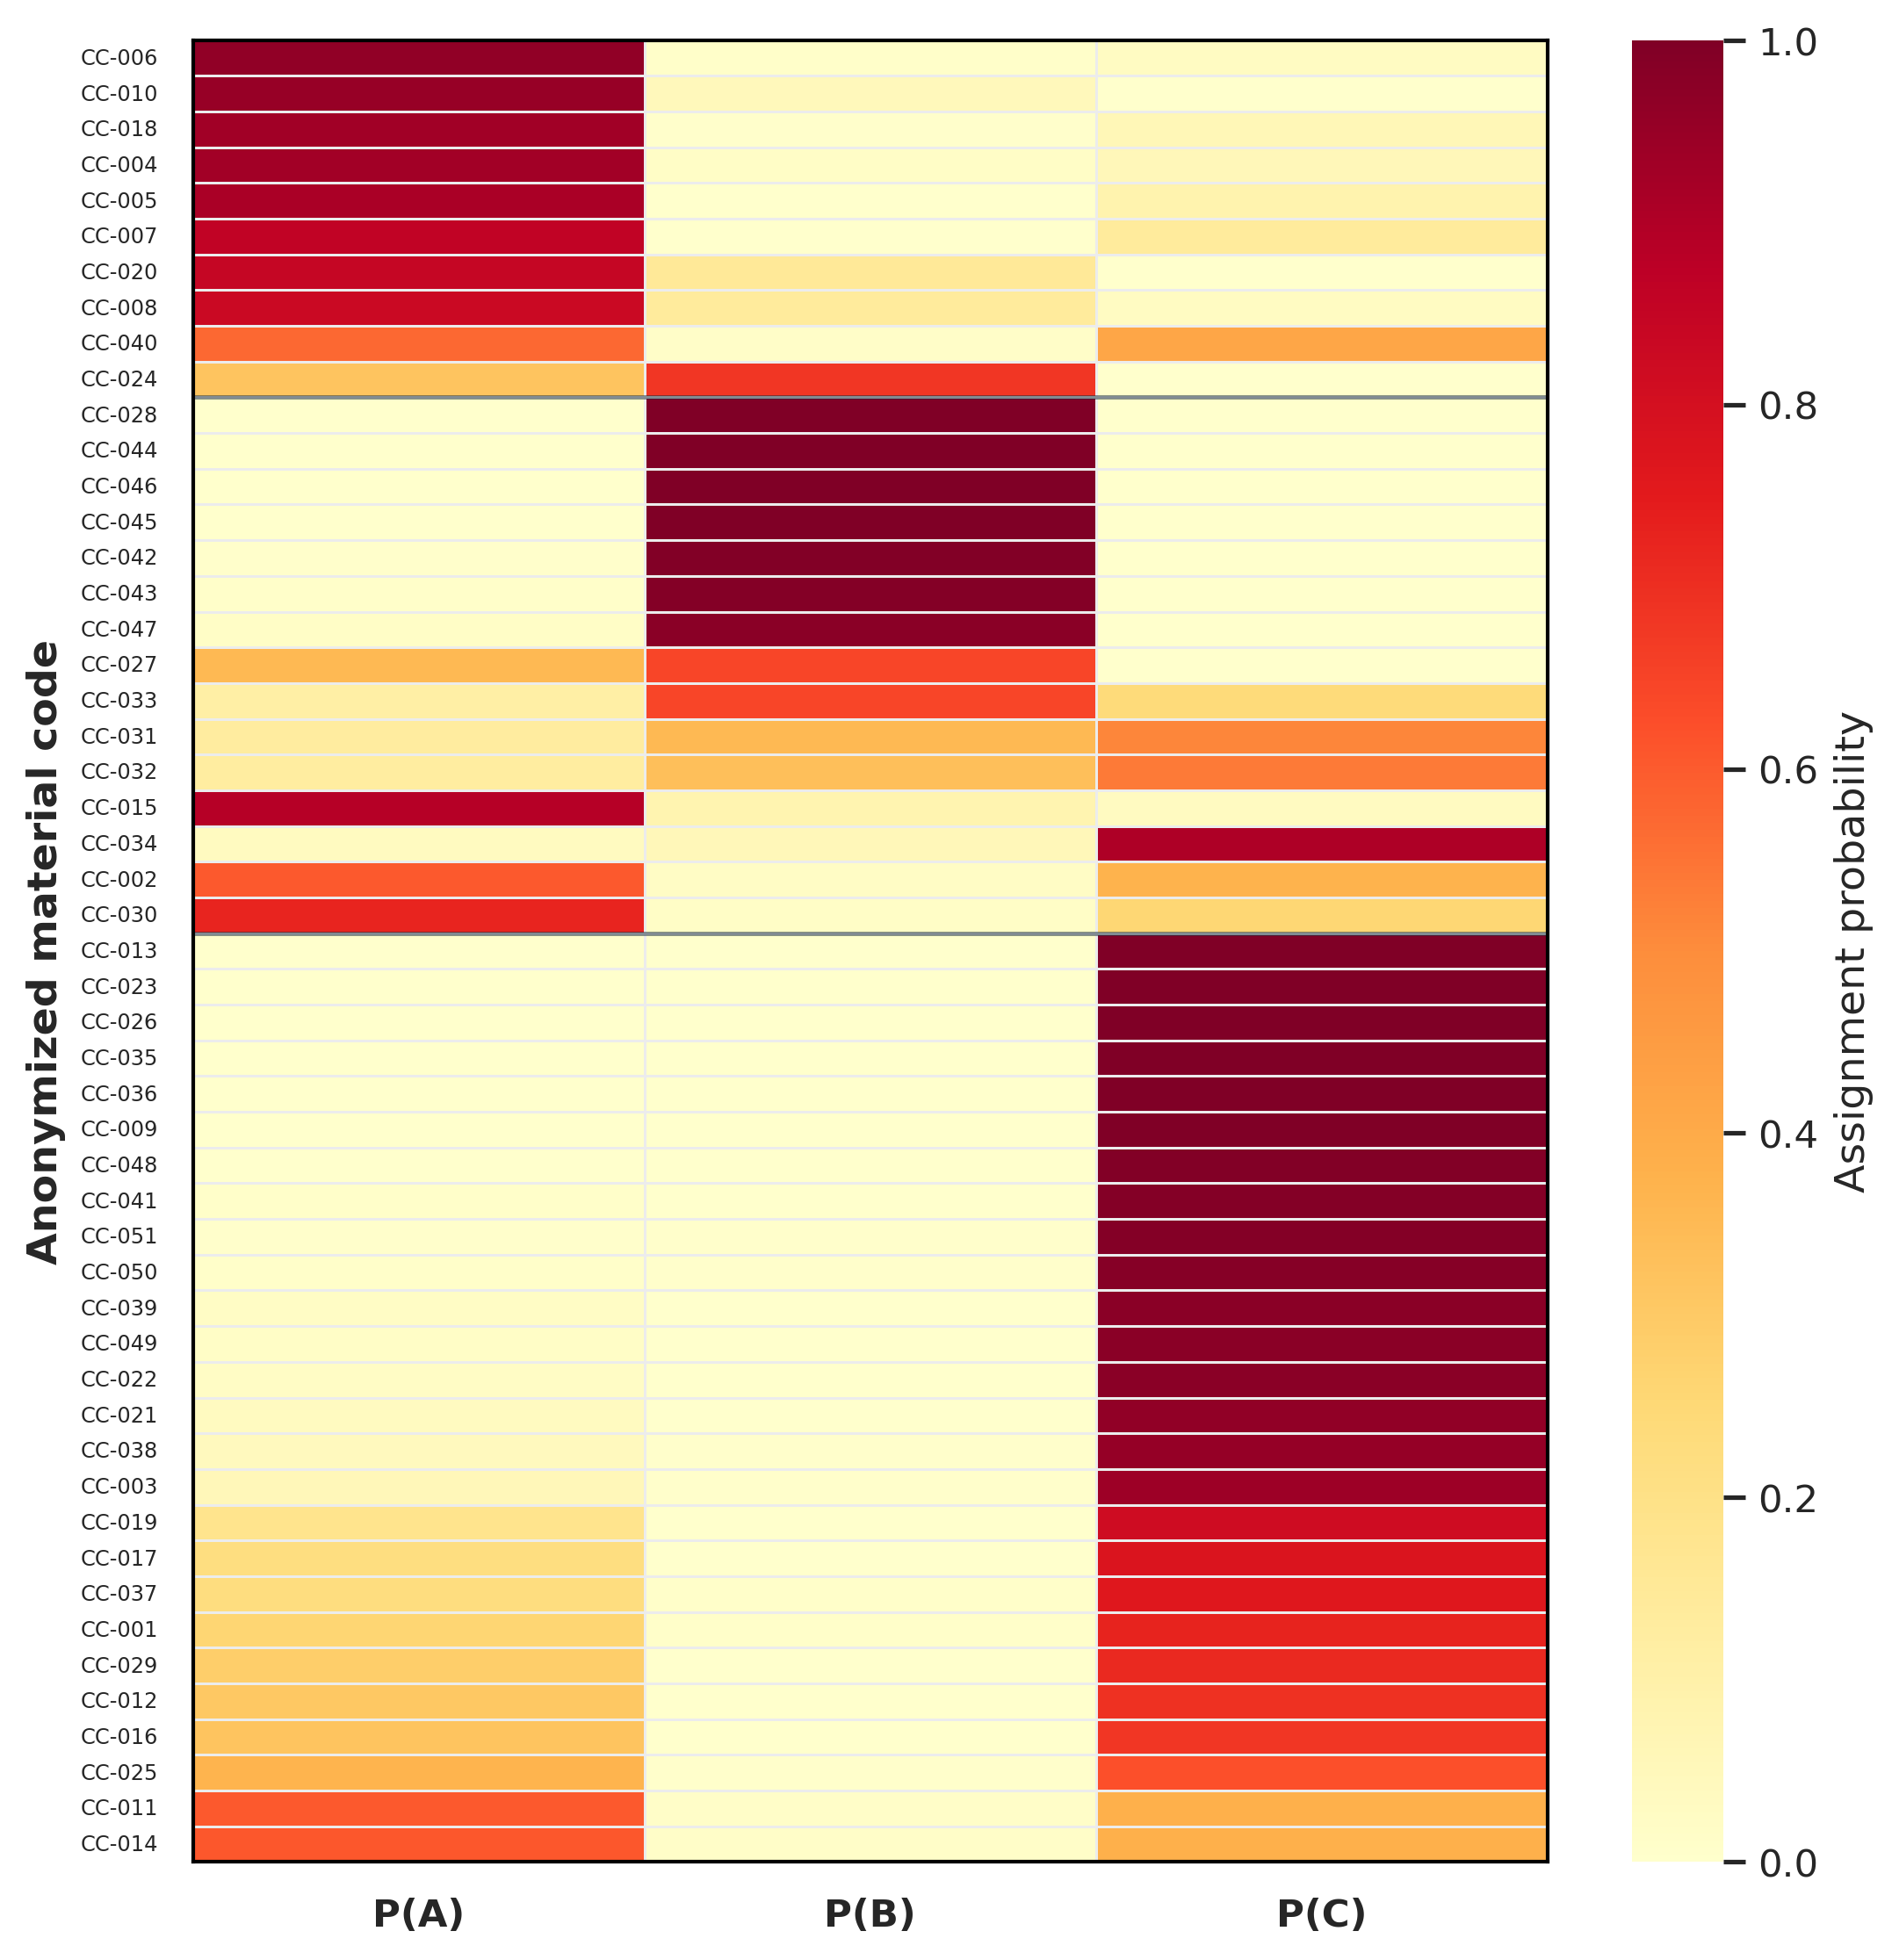

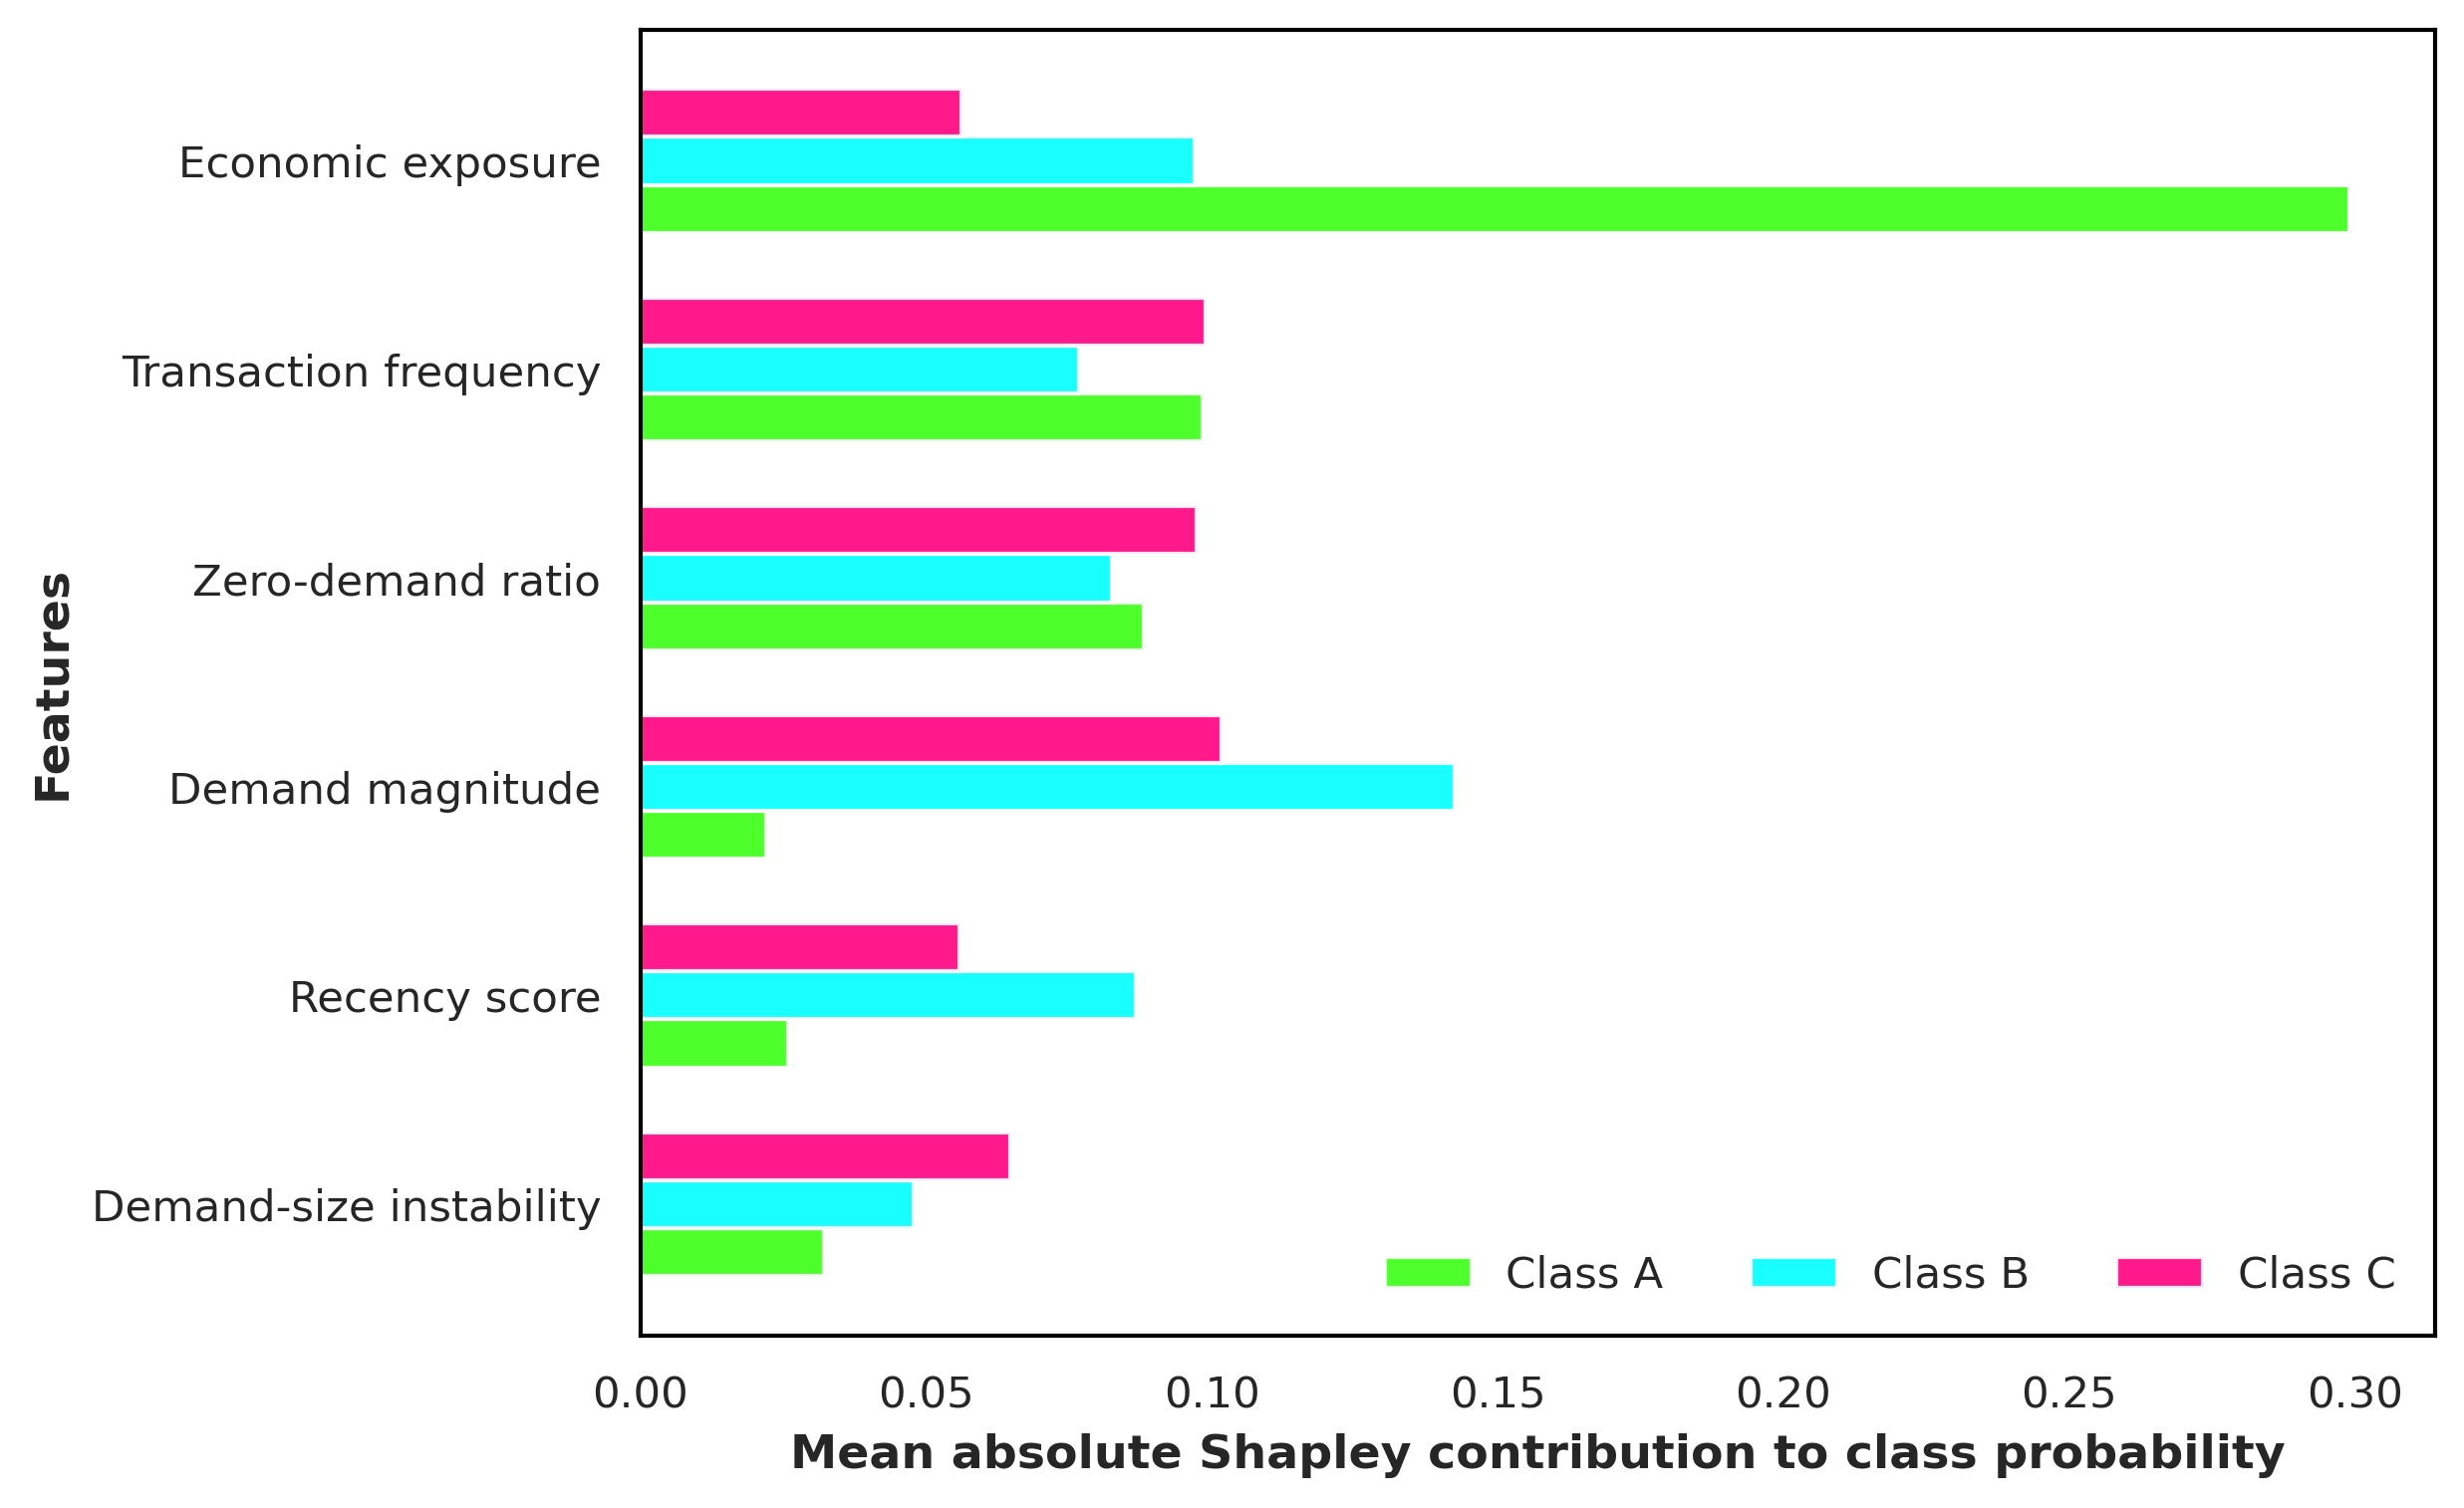

In [10]:
from __future__ import annotations

import argparse

import json
import math
import os
import tempfile
from itertools import combinations
from pathlib import Path
from typing import Iterable

# Avoid failures when a server or container has a read-only user config folder.
os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "prozima-matplotlib-cache")
)

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.cluster import kmeans_plusplus
from sklearn.ensemble import RandomForestClassifier


FEATURES = ["EV", "DM", "TF", "ZR", "DS", "RS"]
FEATURE_LABELS = {
    "EV": "Economic exposure",
    "DM": "Demand magnitude",
    "TF": "Transaction frequency",
    "ZR": "Zero-demand ratio",
    "DS": "Demand-size instability",
    "RS": "Recency score",
}
CLASS_NAMES = ["A", "B", "C"]
# Updated to Neon Colors: Neon Green, Neon Blue, Neon Red/Pink
CLASS_COLORS = {"A": "#39FF14", "B": "#00FFFF", "C": "#FF007F"}
CAPACITIES = np.array([10, 15, 26], dtype=int)
MASTER_SEED = 20250809
PRIMARY_STARTS = 200
BOOTSTRAP_REPS = 500
BOOTSTRAP_STARTS = 30
BLOCK_LENGTH = 3


DEFAULT_DATA = Path("/content/sample_data/Material Item Ledger - Clinker Cooler (1).xlsx")
DEFAULT_FIGURE_DIR = Path("/content/generated_figures")


def require_columns(frame: pd.DataFrame, columns: Iterable[str], sheet: str) -> None:
    """Raise a readable error when a required workbook column is missing."""
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise ValueError(f"Sheet '{sheet}' is missing columns: {', '.join(missing)}")


def percentile_rank(values: pd.Series) -> pd.Series:
    """Map a criterion to [0, 1] using average percentile ranks."""
    n = len(values)
    if n < 2:
        return pd.Series(np.zeros(n), index=values.index, dtype=float)
    return (values.rank(method="average") - 1.0) / (n - 1.0)


def load_raw_ledger(data_path: Path):
    """Load, validate, and reconcile the BOM and issue-ledger sheets."""
    bom_sheet = "Bill of Mat - Clinker Cooler"
    ledger_sheet = "Item Ledger 010120 - 010625"
    bom = pd.read_excel(data_path, sheet_name=bom_sheet)
    ledger = pd.read_excel(data_path, sheet_name=ledger_sheet).iloc[:, :9].copy()
    require_columns(
        ledger,
        ["Material", "Posting Date", "Movement Type", "Qty in Un. of Entry", "Amount in LC"],
        ledger_sheet,
    )
    require_columns(bom, ["No. Material"], bom_sheet)

    ledger["Material"] = ledger["Material"].astype(str).str.strip()
    ledger["Posting Date"] = pd.to_datetime(ledger["Posting Date"], errors="raise")
    ledger["Month"] = ledger["Posting Date"].dt.to_period("M")
    ledger["Qty in Un. of Entry"] = pd.to_numeric(
        ledger["Qty in Un. of Entry"], errors="raise"
    ).abs()
    ledger["AbsAmount"] = pd.to_numeric(ledger["Amount in LC"], errors="raise").abs()
    ledger["UnitValue"] = np.where(
        ledger["AbsAmount"] > 0,
        ledger["AbsAmount"] / ledger["Qty in Un. of Entry"].replace(0, np.nan),
        np.nan,
    )
    material_medians = ledger.groupby("Material")["UnitValue"].median()
    ledger["MedianUnitValue"] = ledger["Material"].map(material_medians)
    ledger["AdjustedValue"] = np.where(
        ledger["AbsAmount"] > 0,
        ledger["AbsAmount"],
        ledger["Qty in Un. of Entry"] * ledger["MedianUnitValue"],
    )
    if ledger.loc[ledger["AbsAmount"].eq(0), "AdjustedValue"].isna().any():
        raise ValueError(
            "At least one zero-valued transaction has no within-material median unit value."
        )

    category_candidates = [
        column for column in bom.columns if str(column).startswith("Kategori Part")
    ]
    if not category_candidates:
        raise ValueError("The BOM sheet has no 'Kategori Part' column.")
    bom["No. Material"] = bom["No. Material"].astype(str).str.strip()
    master_materials = set(bom["No. Material"])
    materials = sorted(ledger["Material"].unique())
    missing = sorted(set(materials) - master_materials)
    if missing:
        raise ValueError(f"Ledger materials absent from the BOM: {missing}")
    if len(materials) != int(CAPACITIES.sum()):
        raise ValueError(
            f"The constrained capacities require {CAPACITIES.sum()} materials, "
            f"but the ledger contains {len(materials)}."
        )
    anonymous_codes = {material: f"CC-{index:03d}" for index, material in enumerate(materials, 1)}
    return ledger, materials, anonymous_codes


def make_monthly_panel(
    ledger: pd.DataFrame,
    materials: list[str],
    start: str = "2021-01",
    end: str = "2025-05",
):
    """Create the complete material-month panel used by the primary model."""
    months = pd.period_range(start, end, freq="M")
    subset = ledger[
        ledger["Month"].between(months[0], months[-1], inclusive="both")
    ].copy()
    index = pd.MultiIndex.from_product(
        [materials, months], names=["Material", "Month"]
    )
    grouped = subset.groupby(["Material", "Month"]).agg(
        quantity=("Qty in Un. of Entry", "sum"),
        transactions=("Material", "size"),
        value=("AdjustedValue", "sum"),
    )
    panel = grouped.reindex(index, fill_value=0).reset_index()
    return panel, months


def calculate_features(panel: pd.DataFrame, months) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Calculate EV, DM, TF, ZR, DS, and RS, then percentile-normalize them."""
    rows = []
    t = len(months)
    for material, group in panel.groupby("Material", sort=False):
        group = group.sort_values("Month")
        quantity = group["quantity"].to_numpy(float)
        transactions = group["transactions"].to_numpy(float)
        value = group["value"].to_numpy(float)
        positive = quantity[quantity > 0]
        active_months = int((quantity > 0).sum())
        cv2 = (
            float((positive.std(ddof=1) / positive.mean()) ** 2)
            if len(positive) > 1 and positive.mean() > 0
            else 0.0
        )
        last_index = int(np.where(quantity > 0)[0].max()) if active_months else -1
        months_since = t - 1 - last_index if active_months else t
        rows.append(
            {
                "Material": material,
                "EV": math.log1p(value.sum()),
                "DM": math.log1p(positive.mean()) if active_months else 0.0,
                "TF": transactions.sum() / t,
                "ZR": 1.0 - active_months / t,
                "DS": math.log1p(cv2),
                "RS": math.exp(-months_since / 12.0),
            }
        )
    raw = pd.DataFrame(rows).set_index("Material")
    normalized = raw[FEATURES].apply(percentile_rank)
    return raw, normalized


def assign_capacity(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """Solve the exact capacity assignment for fixed centroids."""
    costs = ((x[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    slots = np.repeat(np.arange(3), CAPACITIES)
    rows, columns = linear_sum_assignment(costs[:, slots])
    labels = np.empty(len(x), dtype=int)
    labels[rows] = slots[columns]
    return labels


def constrained_start(
    x: np.ndarray,
    seed: int,
    deterministic: bool = False,
    max_iter: int = 300,
) -> dict:
    """Fit one alternating constrained K-means start."""
    rng = np.random.default_rng(seed)
    if deterministic:
        score = x.mean(axis=1)
        targets = np.quantile(score, [0.90, 0.50, 0.10])
        chosen: list[int] = []
        for target in targets:
            order = np.argsort(np.abs(score - target))
            chosen.append(next(int(i) for i in order if int(i) not in chosen))
        centroids = x[chosen].copy()
    else:
        centroids, _ = kmeans_plusplus(
            x, n_clusters=3, random_state=int(rng.integers(0, 2**31 - 1))
        )
        centroids = centroids[np.argsort(centroids.mean(axis=1))[::-1]]

    previous_labels = None
    previous_objective = np.inf
    for iteration in range(1, max_iter + 1):
        labels = assign_capacity(x, centroids)
        new_centroids = np.vstack([x[labels == k].mean(axis=0) for k in range(3)])
        objective = float(((x - new_centroids[labels]) ** 2).sum())
        if previous_labels is not None and np.array_equal(labels, previous_labels):
            centroids = new_centroids
            break
        if abs(previous_objective - objective) <= 1e-10:
            centroids = new_centroids
            break
        previous_labels = labels.copy()
        previous_objective = objective
        centroids = new_centroids
    oriented = bool(np.all(np.diff(centroids.mean(axis=1)) < 0))
    return {
        "labels": labels,
        "centroids": centroids,
        "objective": objective,
        "iterations": iteration,
        "oriented": oriented,
    }


def fit_constrained(x: np.ndarray, n_starts: int, seed: int) -> dict:
    """Keep the lowest-SSE oriented solution across multiple starts."""
    records = [
        constrained_start(x, seed + start, deterministic=(start == 0))
        for start in range(n_starts)
    ]
    eligible = [record for record in records if record["oriented"]] or records
    return min(eligible, key=lambda record: record["objective"])


def panel_arrays(panel: pd.DataFrame, materials: list[str], months):
    """Convert the panel to aligned quantity, transaction, and value matrices."""
    arrays = []
    for column in ["quantity", "transactions", "value"]:
        arrays.append(
            panel.pivot(index="Material", columns="Month", values=column)
            .loc[materials, months]
            .to_numpy(float)
        )
    return tuple(arrays)


def sequence_features(
    quantity: np.ndarray,
    transactions: np.ndarray,
    value: np.ndarray,
    sequence: np.ndarray,
) -> np.ndarray:
    """Recalculate and normalize all features for one bootstrap sequence."""
    q = quantity[:, sequence]
    tr = transactions[:, sequence]
    val = value[:, sequence]
    t = len(sequence)
    raw = np.zeros((q.shape[0], len(FEATURES)), dtype=float)
    for i in range(q.shape[0]):
        positive = q[i, q[i] > 0]
        active = len(positive)
        cv2 = (
            float((positive.std(ddof=1) / positive.mean()) ** 2)
            if active > 1 and positive.mean() > 0
            else 0.0
        )
        last = int(np.where(q[i] > 0)[0].max()) if active else -1
        months_since = t - 1 - last if active else t
        raw[i] = [
            math.log1p(val[i].sum()),
            math.log1p(positive.mean()) if active else 0.0,
            tr[i].sum() / t,
            1.0 - active / t,
            math.log1p(cv2),
            math.exp(-months_since / 12.0),
        ]
    return np.column_stack(
        [percentile_rank(pd.Series(raw[:, j])).to_numpy() for j in range(raw.shape[1])]
    )


def moving_block_indices(t: int, block_length: int, rng) -> np.ndarray:
    """Draw a circularly ordered sequence of contiguous monthly blocks."""
    sequence: list[int] = []
    while len(sequence) < t:
        start = int(rng.integers(0, t - block_length + 1))
        sequence.extend(range(start, start + block_length))
    return np.asarray(sequence[:t], dtype=int)


def align_labels(reference: np.ndarray, candidate: np.ndarray) -> np.ndarray:
    """Align bootstrap class IDs with the primary labels by maximum overlap."""
    contingency = np.zeros((3, 3), dtype=int)
    for primary in range(3):
        for bootstrap in range(3):
            contingency[primary, bootstrap] = int(
                np.sum((reference == primary) & (candidate == bootstrap))
            )
    rows, columns = linear_sum_assignment(-contingency)
    mapping = {int(column): int(row) for row, column in zip(rows, columns)}
    return np.asarray([mapping[int(label)] for label in candidate], dtype=int)


def bootstrap_probabilities(
    quantity: np.ndarray,
    transactions: np.ndarray,
    value: np.ndarray,
    primary_labels: np.ndarray,
    repetitions: int,
    starts: int,
    block_length: int,
) -> np.ndarray:
    """Estimate class-assignment probabilities with moving-block bootstrap."""
    rng = np.random.default_rng(MASTER_SEED + 90000)
    all_labels = np.zeros((repetitions, len(primary_labels)), dtype=int)
    for repetition in range(repetitions):
        sequence = moving_block_indices(quantity.shape[1], block_length, rng)
        x_bootstrap = sequence_features(quantity, transactions, value, sequence)
        best = fit_constrained(
            x_bootstrap,
            n_starts=starts,
            seed=MASTER_SEED + 100000 + repetition * 100,
        )
        all_labels[repetition] = align_labels(primary_labels, best["labels"])
        if (repetition + 1) % 50 == 0 or repetition + 1 == repetitions:
            print(f"Bootstrap {repetition + 1}/{repetitions}")
    return np.column_stack([(all_labels == k).mean(axis=0) for k in range(3)])


def exact_interventional_shapley(model, x: np.ndarray) -> np.ndarray:
    """Calculate exact six-feature interventional Shapley contributions."""
    n, m = x.shape
    classes = len(model.classes_)
    masks = np.arange(2**m, dtype=int)
    coalition_values = np.zeros((n, len(masks), classes), dtype=float)
    for i in range(n):
        blocks = []
        for mask in masks:
            block = x.copy()
            for feature in range(m):
                if mask & (1 << feature):
                    block[:, feature] = x[i, feature]
            blocks.append(block)
        predictions = model.predict_proba(np.vstack(blocks)).reshape(len(masks), n, classes)
        coalition_values[i] = predictions.mean(axis=1)

    shapley = np.zeros((n, m, classes), dtype=float)
    denominator = math.factorial(m)
    for feature in range(m):
        others = [index for index in range(m) if index != feature]
        for size in range(m):
            weight = math.factorial(size) * math.factorial(m - size - 1) / denominator
            for subset in combinations(others, size):
                mask = sum(1 << index for index in subset)
                shapley[:, feature, :] += weight * (
                    coalition_values[:, mask | (1 << feature), :]
                    - coalition_values[:, mask, :]
                )
    return shapley


def analyze_raw_workbook(
    data_path: Path,
    primary_starts: int,
    bootstrap_reps: int,
    bootstrap_starts: int,
    block_length: int,
) -> tuple[dict[str, pd.DataFrame], dict]:
    """Run the complete primary analysis and return figure-ready tables."""
    if not data_path.exists():
        raise FileNotFoundError(f"Raw workbook not found: {data_path}")
    ledger, materials, anonymous_codes = load_raw_ledger(data_path)
    panel, months = make_monthly_panel(ledger, materials)
    raw, normalized = calculate_features(panel, months)
    x = normalized.loc[materials, FEATURES].to_numpy(float)

    print(f"Fitting primary constrained model ({primary_starts} starts) ...")
    best = fit_constrained(x, n_starts=primary_starts, seed=MASTER_SEED)
    labels = best["labels"]
    class_labels = np.asarray(CLASS_NAMES)[labels]

    quantity, transactions, value = panel_arrays(panel, materials, months)
    probabilities = bootstrap_probabilities(
        quantity,
        transactions,
        value,
        labels,
        repetitions=bootstrap_reps,
        starts=bootstrap_starts,
        block_length=block_length,
    )
    assigned_probabilities = probabilities[np.arange(len(labels)), labels]

    print("Fitting shallow surrogate and calculating exact Shapley values ...")
    surrogate = RandomForestClassifier(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=MASTER_SEED,
        n_jobs=-1,
    )
    surrogate.fit(x, labels)
    shapley = exact_interventional_shapley(surrogate, x)
    class_contributions = np.zeros((3, len(FEATURES)))
    for class_index in range(3):
        class_contributions[class_index] = np.mean(
            np.abs(shapley[labels == class_index, :, class_index]), axis=0
        )

    items = normalized.loc[materials, FEATURES].copy()
    items["AnonymousCode"] = [anonymous_codes[material] for material in materials]
    items["Class"] = class_labels
    items["BootstrapProbability"] = assigned_probabilities
    items.index.name = "Material"

    bootstrap = pd.DataFrame(
        probabilities, columns=["P(A)", "P(B)", "P(C)"], index=materials
    )
    bootstrap["AssignedClass"] = class_labels
    bootstrap["AssignedProbability"] = assigned_probabilities
    bootstrap["AnonymousCode"] = [anonymous_codes[material] for material in materials]

    shapley_global = pd.DataFrame(
        class_contributions.T,
        index=FEATURES,
        columns=["Class A", "Class B", "Class C"],
    )
    shapley_global["Overall"] = shapley_global.mean(axis=1)
    summary = {
        "source_workbook": str(data_path),
        "materials": len(materials),
        "months": len(months),
        "window": [str(months[0]), str(months[-1])],
        "class_counts": {
            class_name: int(np.sum(class_labels == class_name)) for class_name in CLASS_NAMES
        },
        "objective_sse": float(best["objective"]),
        "primary_starts": primary_starts,
        "bootstrap_repetitions": bootstrap_reps,
        "bootstrap_starts": bootstrap_starts,
        "block_length_months": block_length,
        "random_seed": MASTER_SEED,
    }
    return {"items": items, "bootstrap": bootstrap, "shapley": shapley_global}, summary


def save_pca_projection(items: pd.DataFrame, output_path: Path, dpi: int) -> None:
    """Create the PCA class-projection figure used as Figure 1."""
    x = items[FEATURES].to_numpy(dtype=float)
    labels = items["Class"].astype(str).to_numpy()
    pca = PCA(n_components=2, random_state=MASTER_SEED)
    coordinates = pca.fit_transform(x)

    centroid_matrix = np.vstack(
        [x[labels == class_name].mean(axis=0) for class_name in CLASS_NAMES]
    )
    centroid_coordinates = pca.transform(centroid_matrix)

    # Annotate one central class-A item and the least stable item
    class_a_indices = np.flatnonzero(labels == "A")
    distances_a = np.linalg.norm(
        x[class_a_indices] - centroid_matrix[0], axis=1
    )
    representative_index = int(class_a_indices[np.argmin(distances_a)])
    borderline_index = int(np.argmin(items["BootstrapProbability"].to_numpy(float)))

    fig, axis = plt.subplots(figsize=(8.6, 5.6))
    # Completely remove all grid lines and zero axes for a clean background
    axis.grid(False, which='both')
    axis.xaxis.grid(False)
    axis.yaxis.grid(False)

    for class_index, class_name in enumerate(CLASS_NAMES):
        mask = labels == class_name
        axis.scatter(
            coordinates[mask, 0],
            coordinates[mask, 1],
            s=58,
            alpha=0.9,
            c=CLASS_COLORS[class_name],
            edgecolor="black",
            linewidth=0.5,
            label=f"Class {class_name} (n={int(mask.sum())})",
        )
        axis.scatter(
            centroid_coordinates[class_index, 0],
            centroid_coordinates[class_index, 1],
            s=230,
            marker="X",
            c=CLASS_COLORS[class_name],
            edgecolor="#172B3A",
            linewidth=1.2,
        )

    for item_index in dict.fromkeys([representative_index, borderline_index]):
        axis.annotate(
            str(items.iloc[item_index]["AnonymousCode"]),
            (coordinates[item_index, 0], coordinates[item_index, 1]),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=8.5,
            weight="bold",
            color="#172B3A",
        )

    axis.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)", weight="bold")
    axis.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)", weight="bold")
    # Removed title as per user request
    axis.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    # Explicitly enable all spines to show the full box border
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def save_bootstrap_heatmap(bootstrap: pd.DataFrame, output_path: Path, dpi: int) -> None:
    """Create the assignment-probability heatmap used as Figure 2."""
    frame = bootstrap.copy()
    class_order = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
    label_indices = frame["AssignedClass"].map(class_order).to_numpy()
    if pd.isna(label_indices).any():
        raise ValueError("Sheet 'bootstrap_probs' contains an unexpected AssignedClass value.")
    probabilities = frame[["P(A)", "P(B)", "P(C)"]].to_numpy(dtype=float)
    label_indices = label_indices.astype(int)
    assigned_probabilities = probabilities[np.arange(len(frame)), label_indices]
    order = np.lexsort((-assigned_probabilities, label_indices))
    frame = frame.iloc[order].reset_index(drop=True)
    probabilities = probabilities[order]
    label_indices = label_indices[order]
    fig, axis = plt.subplots(figsize=(7.4, 7.6))
    sns.heatmap(
        probabilities,
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0.25,
        linecolor="#ECECEC",
        cbar_kws={"label": "Assignment probability"},
        ax=axis,
    )
    axis.set_xticklabels(["P(A)", "P(B)", "P(C)"], rotation=0, weight="bold")
    axis.set_yticks(np.arange(len(frame)) + 0.5)
    axis.set_yticklabels(frame["AnonymousCode"], rotation=0, fontsize=5.8)
    axis.set_xlabel("", weight="bold")
    axis.set_ylabel("Anonymized material code", weight="bold")
    # Removed title as per user request

    class_counts = [int((label_indices == index).sum()) for index in range(3)]
    for boundary in np.cumsum(class_counts)[:-1]:
        axis.axhline(int(boundary), color="#172B3A", linewidth=1.2, alpha=0.5)

    # Ensure heatmap has outer border
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def save_global_shapley(shapley: pd.DataFrame, output_path: Path, dpi: int) -> None:
    """Create the class-specific global Shapley plot used as Figure 3."""
    missing_features = [feature for feature in FEATURES if feature not in shapley.index]
    if missing_features:
        raise ValueError(
            "Sheet 'shapley_global' is missing features: " + ", ".join(missing_features)
        )
    ordered = shapley.loc[FEATURES].sort_values("Overall", ascending=True)
    y_positions = np.arange(len(ordered))
    bar_height = 0.23

    fig, axis = plt.subplots(figsize=(8.4, 5.2))
    for class_name, offset in zip(CLASS_NAMES, [-bar_height, 0, bar_height]):
        axis.barh(
            y_positions + offset,
            ordered[f"Class {class_name}"],
            height=bar_height,
            color=CLASS_COLORS[class_name],
            alpha=0.9,
            label=f"Class {class_name}",
        )
    axis.set_yticks(y_positions)
    axis.set_yticklabels([FEATURE_LABELS[feature] for feature in ordered.index])
    axis.set_xlabel("Mean absolute Shapley contribution to class probability", weight="bold")
    axis.set_ylabel("Features", weight="bold")
    # Removed title as per user request
    axis.legend(frameon=False, ncol=3, loc="lower right")
    # Explicitly enable all spines for global surrogate plot
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

    fig.tight_layout()
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)


def generate_figures(
    data_path: Path,
    figure_dir: Path,
    dpi: int,
    primary_starts: int,
    bootstrap_reps: int,
    bootstrap_starts: int,
    block_length: int,
) -> tuple[list[Path], dict]:
    """Run the raw-data analysis and save the three PNG figures."""
    figure_dir.mkdir(parents=True, exist_ok=True)
    figure_paths = [
        figure_dir / "Figure_1_cluster_projection.png",
        figure_dir / "Figure_2_assignment_stability.png",
        figure_dir / "Figure_3_global_shapley.png",
    ]
    analysis, summary = analyze_raw_workbook(
        data_path,
        primary_starts=primary_starts,
        bootstrap_reps=bootstrap_reps,
        bootstrap_starts=bootstrap_starts,
        block_length=block_length,
    )
    sns.set_theme(style="white", font_scale=0.95)
    save_pca_projection(analysis["items"], figure_paths[0], dpi)
    save_bootstrap_heatmap(analysis["bootstrap"], figure_paths[1], dpi)
    save_global_shapley(analysis["shapley"], figure_paths[2], dpi)
    summary_path = figure_dir / "analysis_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return figure_paths, summary


def display_figures_in_notebook(figure_paths: list[Path]) -> None:
    """Display generated PNGs when the script is executed through IPython/Colab."""
    try:
        from IPython import get_ipython
        from IPython.display import Image as IPythonImage
        from IPython.display import display
    except ImportError:
        return
    if get_ipython() is None:
        return
    for figure_path in figure_paths:
        display(IPythonImage(filename=str(figure_path)))


def main() -> None:
    figure_paths, summary = generate_figures(
        data_path=DEFAULT_DATA.resolve(),
        figure_dir=DEFAULT_FIGURE_DIR.resolve(),
        dpi=300,
        primary_starts=PRIMARY_STARTS,
        bootstrap_reps=BOOTSTRAP_REPS,
        bootstrap_starts=BOOTSTRAP_STARTS,
        block_length=BLOCK_LENGTH,
    )
    for figure_path in figure_paths:
        print(f"Saved figure: {figure_path.resolve()}")
    display_figures_in_notebook(figure_paths)


main()